# Construct End-User Parquet Files

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
from utils import load_root_file, load_hepmc_event
from edm4hep_utils import build_calo_df, build_particle_df, build_tracker_df, load_edm4hep_file
from clustering_metrics import evaluate_clustering, plot_clustering_metrics

from edm4hep_utils import pixel_readouts, strip_readouts
all_tracker_readouts = pixel_readouts + strip_readouts

## Roadmap

1. Load in edm4hep file
2. Load in ambi tracks csv 
3. Load in particles root
4. Load in measurements root
5. Load in trackstates ambi root
6. Load in tracksummary ambi root
7. Create track parquet object
8. Track object needs:
    - hits in the track (hit ID)
    - track fit parameters
    - track quality parameters
    - track states at IP, end-of-track, first hit, last hit

# Loading

## 1. Load in edm4hep file

In [2]:
edm4hep_file = "/eos/home-d/dmurnane/www/ColliderML/simulation/gg2ttbar/v1/runs/0/edm4hep.root"
# edm4hep_file = "/eos/home-d/dmurnane/www/ColliderML/simulation/chichi/v1/runs/0/edm4hep.root"
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [3]:
event.keys()

dict_keys(['tracker_df', 'calo_hits_df', 'calo_contrib_df', 'particles_df', 'parents_df', 'daughters_df'])

In [174]:
def get_particle_ids_from_events(events, tracker_readouts):
    """Get particle IDs from events for each tracker readout.
    
    Args:
        events: uproot events object
        tracker_readouts: list of tracker readout names
        
    Returns:
        DataFrame containing event_id and particle_id columns
    """
    all_particle_ids = []
    for det in tracker_readouts:
        if det not in events:
            continue
        hits = events[det].arrays()
        hits_df = ak.to_dataframe(hits[[f"{det}.position.x", f"{det}.position.y", f"{det}.position.z"]]).reset_index(drop=False).rename(columns={"entry": "event_id", f"{det}.position.x": "x", f"{det}.position.y": "y", f"{det}.position.z": "z"}).drop(columns=["subentry"])
        particle_links = events[f"_{det}_MCParticle"].arrays()
        particle_links_df = ak.to_dataframe(particle_links[f"_{det}_MCParticle.index"]) \
            .reset_index(drop=False) \
            .rename(columns={"entry": "event_id", "values": "particle_id"}) \
            .drop(columns=["subentry"])
        # horizontal concat
        hits_df = pd.concat([hits_df, particle_links_df], axis=1)
        all_particle_ids.append(hits_df)

    particle_ids = pd.concat(all_particle_ids, ignore_index=True)
    return particle_ids

particle_ids = get_particle_ids_from_events(events, all_tracker_readouts)
particle_ids


,event_id,x,y,z,event_id,particle_id
0,0,-32.366956,1.492748,-401.924170,0,8352
1,0,2.450572,-31.891473,-346.345357,0,8350
2,0,41.731344,-165.855602,-459.294072,0,9944
3,0,42.007489,-165.670502,-459.724257,0,9944
4,0,-31.250231,6.906123,-266.890574,0,8347
...,...,...,...,...,...,...
174019,9,280.910245,-718.181977,1579.500000,9,503348
174020,9,112.264841,-755.496353,1874.500000,9,503348
174021,9,109.257986,-755.459817,1879.500000,9,503348
174022,9,955.142649,274.883962,2620.500000,9,503595


In [4]:
tracker_df = event["tracker_df"]
tracker_df.columns

Index(['cellID', 'EDep', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px',
       'py', 'pz', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [5]:
calo_df = event["calo_contrib_df"]
calo_df.columns

Index(['PDG', 'energy', 'time', 'x', 'y', 'z', 'particle_id', 'detector'], dtype='object')

In [11]:
parents_df = event["parents_df"]
parents_df.columns

particles_df = event["particles_df"]
# Create a column from the index
particles_df["particle_id"] = particles_df.index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'particle_id'],
      dtype='object')

# Create Particle Object

In [188]:
particle_barcode_map

particle_id
5845003847824473    284097
7260075580901193     97309
8995104811581868      3358
7554744730876962     66624
8129789278719944     94182
                     ...  
8200157754724050    291493
8992905638842669    404466
4836751819432257    219993
7362330195852973     16444
8645460232209618    119919
Name: particle_barcode, Length: 3869, dtype: int32

In [190]:
particles_root_df

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_primary,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome
entry,,,,,,,,,,,,,,,,,,,,,
0,0,4504699155841029,-2,0,0.003543,-0.005813,-105.372108,2425.787842,-3.244334,1.407285,...,1,1,1,1,5,12.115084,0.0,0.0,0,0
1,0,4504699155841032,-1,0,0.003543,-0.005813,-105.372108,2425.787842,-2.774586,-0.292908,...,1,1,1,1,8,12.869830,0.0,0.0,0,0
2,0,4542082569470722,-211,0,0.003543,-0.005813,-105.372108,2425.787842,1.175650,0.272212,...,1,35,2,24,770,2.083743,0.0,0.0,0,0
3,0,4592660372048331,211,0,0.009781,0.014497,-116.807983,3995.353760,-0.969926,-0.885298,...,1,81,18,12,51659,5.592474,0.0,0.0,0,0
4,0,4621247405833537,3,0,0.003543,-0.005813,-105.372108,2425.787842,-1.653649,-0.264909,...,1,107,2,11,15681,1.554827,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,0,8988507592132378,-2212,0,0.003543,-0.005813,-105.372108,2425.787842,3.789078,-0.840354,...,1,4079,2,23,1818,37.361057,0.0,0.0,0,0
324,0,8988507592132379,213,0,0.003543,-0.005813,-105.372108,2425.787842,6.949781,-1.863585,...,1,4079,2,23,1819,68.278442,0.0,0.0,0,0
325,0,8989607103824618,11,0,0.643046,-0.055682,-106.382172,2427.019775,3.200787,-0.905479,...,1,4080,2,24,746,7.821862,0.0,0.0,0,0


In [193]:
(~particles_root_df["particle_id"].map(particle_barcode_map).isna()).sum()


np.int64(117)

In [ ]:
particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,7000.000000,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457764,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885193,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841492,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382065,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406500,11,0,1493172224,-1.000000,19.541965,0.000511,-299.902636,1145.078819,2991.900520,-0.000953,...,1141.891321,2995.630804,425960,425961,425965,425965,0.002750,0.004253,1.002901,-1.924785
406501,11,0,1493172224,-1.000000,24.605585,0.000511,-821.447430,-263.918514,3208.522889,-0.000823,...,-265.622790,3208.615996,425961,425962,425965,425965,0.003097,0.003221,0.281592,-1.839849
406502,11,0,1493172224,-1.000000,20.544994,0.000511,-485.961906,1084.170673,3200.297544,-0.000461,...,1084.139483,3200.321416,425962,425963,425965,425965,0.001174,0.001435,0.655716,-1.974886
406503,11,0,1493172224,-1.000000,20.208435,0.000511,-223.787133,1091.063616,3215.822788,0.000249,...,1091.005626,3215.876509,425963,425964,425965,425965,0.001502,0.002022,0.809731,-1.404139


In [6]:
particles_df[particles_df.simulatorStatus != 0]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
75,211,1,33554432,1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,0.178090,...,13.780250,-10000.000000,75,77,229,229,0.233295,105.244026,-6.804880,0.702282
76,223,2,134217728,0.0,8.091558,0.792004,0.003543,-0.005813,-105.372111,0.758787,...,-0.005813,-105.372111,77,79,229,232,0.914713,128.128616,-5.635314,0.592521
77,-211,1,33554432,-1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,0.025495,...,-136.082377,-10000.000000,79,81,232,233,0.123983,8.778193,-4.952981,-1.363681
78,321,1,33554432,1.0,8.091558,0.493680,0.003543,-0.005813,-105.372111,0.582114,...,38.261012,-10000.000000,81,83,233,233,0.830237,151.731934,-5.901299,0.793799
79,-311,2,134217728,0.0,8.091558,0.497610,0.003543,-0.005813,-105.372111,-0.435763,...,-0.005813,-105.372111,83,85,233,234,0.684588,12.998700,-3.636241,-2.260791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406500,11,0,1493172224,-1.0,19.541965,0.000511,-299.902636,1145.078819,2991.900520,-0.000953,...,1141.891321,2995.630804,425960,425961,425965,425965,0.002750,0.004253,1.002901,-1.924785
406501,11,0,1493172224,-1.0,24.605585,0.000511,-821.447430,-263.918514,3208.522889,-0.000823,...,-265.622790,3208.615996,425961,425962,425965,425965,0.003097,0.003221,0.281592,-1.839849
406502,11,0,1493172224,-1.0,20.544994,0.000511,-485.961906,1084.170673,3200.297544,-0.000461,...,1084.139483,3200.321416,425962,425963,425965,425965,0.001174,0.001435,0.655716,-1.974886
406503,11,0,1493172224,-1.0,20.208435,0.000511,-223.787133,1091.063616,3215.822788,0.000249,...,1091.005626,3215.876509,425963,425964,425965,425965,0.001502,0.002022,0.809731,-1.404139


In [197]:
np.unique(particles_df["generatorStatus"], return_counts=True)


(array([ 0,  1,  2,  4, 13, 15, 21, 22, 23, 31, 33, 41, 42, 43, 44, 51, 52,
        53, 61, 62, 63, 71, 73], dtype=int32),
 array([398057,   2768,   1397,     22,      4,      2,     20,      4,
            24,     86,     86,    130,    130,    130,    569,    972,
           437,     49,    106,    701,     47,    557,    207]))

In [198]:
def is_physical_particle(row):
    """
    Filter for physically relevant particles:
    - Status 1: Final state stable particle
    - Status 2: Decayed particle that reached the detector
    - Status 4: Beam particle
    """
    # Convert simulatorStatus to int64 for bitwise operations
    sim_status = np.int64(row['simulatorStatus'])
    
    # Stable final state particles
    if row['generatorStatus'] == 1:
        return True
        
    # Check simulator status for particles that interacted with detector
    detector_track = bool(sim_status & np.int64(0x0FF00000))
    
    return detector_track

# First ensure simulatorStatus is numeric
particles_df['simulatorStatus'] = pd.to_numeric(particles_df['simulatorStatus'], errors='coerce')

# Then apply filter
physical_particles_df = particles_df[particles_df.apply(is_physical_particle, axis=1)]

# Let's see what we got
print(f"Total particles: {len(particles_df)}")
print(f"Physical particles: {len(physical_particles_df)}")
print("\nSample of physical particles:")
print(physical_particles_df[['PDG', 'generatorStatus', 'simulatorStatus', 'charge']].head())

Total particles: 406505
Physical particles: 402213

Sample of physical particles:
    PDG  generatorStatus  simulatorStatus  charge
75  211                1         33554432     1.0
76  223                2        134217728     0.0
77 -211                1         33554432    -1.0
78  321                1         33554432     1.0
79 -311                2        134217728     0.0


In [199]:
print("Generator Status distribution:")
print(np.unique(particles_df["generatorStatus"], return_counts=True))

print("\nSimulator Status distribution (most common):")
print(particles_df["simulatorStatus"].value_counts().head(10))

Generator Status distribution:
(array([ 0,  1,  2,  4, 13, 15, 21, 22, 23, 31, 33, 41, 42, 43, 44, 51, 52,
       53, 61, 62, 63, 71, 73], dtype=int32), array([398057,   2768,   1397,     22,      4,      2,     20,      4,
           24,     86,     86,    130,    130,    130,    569,    972,
          437,     49,    106,    701,     47,    557,    207]))

Simulator Status distribution (most common):
simulatorStatus
1493172224    232602
1224736768    146912
1426063360      7961
1157627904      6525
0               4296
1207959552      1531
134217728       1388
1107296256      1351
33554432        1088
150994944       1064
Name: count, dtype: int64


In [36]:
# Neutralinos with mass 2.04229580e+02, pdf id 1000021
particles_df[particles_df.PDG == 1000023][["PDG", "mass", "generatorStatus", "simulatorStatus", "charge", "px", "py", "pz"]]

,PDG,mass,generatorStatus,simulatorStatus,charge,px,py,pz
576,1000023,385.342203,22,0,0.0,576.716797,614.295105,-1494.700317
577,1000023,385.342203,22,0,0.0,-576.716797,-614.295105,-566.135986
645,1000023,385.342203,44,0,0.0,612.710022,652.596802,-1626.515503
646,1000023,385.342203,44,0,0.0,-505.832733,-538.864746,-388.696381
678,1000023,385.342203,44,0,0.0,614.381775,660.740723,-1626.732056
679,1000023,385.342203,44,0,0.0,-505.211823,-535.839966,-391.158447
695,1000023,385.342203,44,0,0.0,621.175171,665.254761,-1624.806030
696,1000023,385.342203,44,0,0.0,-502.688629,-534.163330,-392.868469
725,1000023,385.342203,44,0,0.0,622.416931,666.217529,-1629.668457
726,1000023,385.342203,44,0,0.0,-500.339203,-532.341797,-388.652863


In [34]:
parents_df.iloc[1456]

particle_id            428
collectionID    2714477136
Name: 1456, dtype: int64

In [194]:
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [42]:
particles_with_hits = particles_df.iloc[np.unique(np.concatenate([tracker_df.particle_id.unique(), calo_df.particle_id.unique()]))]

In [52]:
n_hits.particle_id

0          154
1          155
2          159
3          160
4          162
         ...  
1875    158201
1876    163201
1877    176722
1878    178180
1879    181893
Name: particle_id, Length: 1880, dtype: int32

In [53]:
n_hits.n_hits

0       14
1       13
2       12
3       12
4       10
        ..
1875     5
1876     2
1877     1
1878     2
1879     1
Name: n_hits, Length: 1880, dtype: int64

In [9]:
calo_df

,PDG,energy,time,x,y,z,particle_id,detector
0,0,2.416614e-05,312.383392,0.0,0.0,0.0,8352,ECalBarrelCollection
1,0,6.632625e-05,120.258148,0.0,0.0,0.0,8455,ECalBarrelCollection
2,0,7.453639e-05,7668.329590,0.0,0.0,0.0,8592,ECalBarrelCollection
3,0,2.974118e-05,7679.745117,0.0,0.0,0.0,8592,ECalBarrelCollection
4,0,1.697715e-05,7679.745605,0.0,0.0,0.0,8592,ECalBarrelCollection
...,...,...,...,...,...,...,...,...
761504,0,6.907979e-09,4799.214355,0.0,0.0,0.0,1754,HCalEndcapCollection
761505,0,2.598804e-04,24.107910,0.0,0.0,0.0,1754,HCalEndcapCollection
761506,0,4.960612e-05,24.099184,0.0,0.0,0.0,1754,HCalEndcapCollection
761507,0,5.468227e-05,24.303453,0.0,0.0,0.0,1754,HCalEndcapCollection


In [18]:
# Group the tracker DataFrame by particle_id to count hits
n_tracker_hits = tracker_df.groupby("particle_id").size().reset_index(name="n_tracker_hits")
n_calo_hits = calo_df.groupby("particle_id").size().reset_index(name="n_calo_hits")


# Set particle_id as index in particles_df and initialize n_hits to 0
particles_df["n_tracker_hits"] = 0
particles_df["n_calo_hits"] = 0
# Update n_hits using .loc to align on the index (particle_id)
particles_df.loc[n_tracker_hits["particle_id"], "n_tracker_hits"] = n_tracker_hits["n_tracker_hits"].values
particles_df.loc[n_calo_hits["particle_id"], "n_calo_hits"] = n_calo_hits["n_calo_hits"].values

In [13]:
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'particle_id',
       'n_tracker_hits', 'n_calo_hits', 'n_hits'],
      dtype='object')

In [21]:
full_particles_columns = [
    "particle_id",
    "PDG",
    "mass",
    "charge",
    "vx",
    "vy",
    "vz",
    "px",
    "py",
    "pz",
    "n_tracker_hits",
    "n_calo_hits",
]
full_particle_df = particles_df[full_particles_columns].rename(columns={"PDG": "pdg_id"})
full_particle_df.head()

,particle_id,pdg_id,mass,charge,vx,vy,vz,px,py,pz,n_tracker_hits,n_calo_hits
0,0,2212,0.93827,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7000.000000,0,0
1,1,1,0.00000,-0.333333,0.003543,-0.005813,-105.372111,2.672720,-0.225431,2607.456299,0,0
2,2,1,0.00000,-0.333333,0.003543,-0.005813,-105.372111,-0.115590,-0.485282,376.884857,0,0
3,3,21,0.00000,0.000000,0.003543,-0.005813,-105.372111,-0.391733,-1.676179,267.835968,0,0
4,4,1,0.00000,-0.333333,0.003543,-0.005813,-105.372111,3.310610,0.479107,155.346054,0,0


<Axes: xlabel='n_tracker_hits', ylabel='Count'>

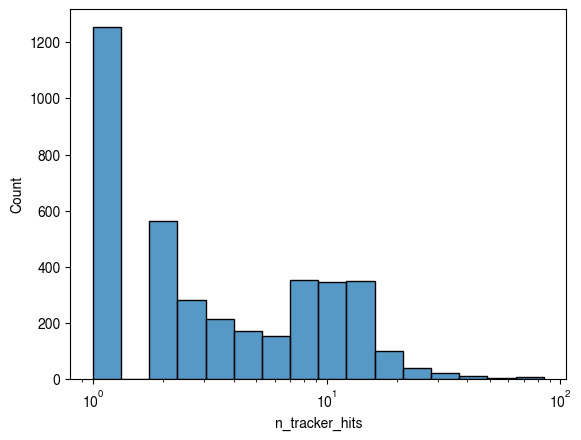

In [24]:
sns.histplot(full_particle_df.n_tracker_hits, log_scale=True)

<Axes: xlabel='n_calo_hits', ylabel='Count'>

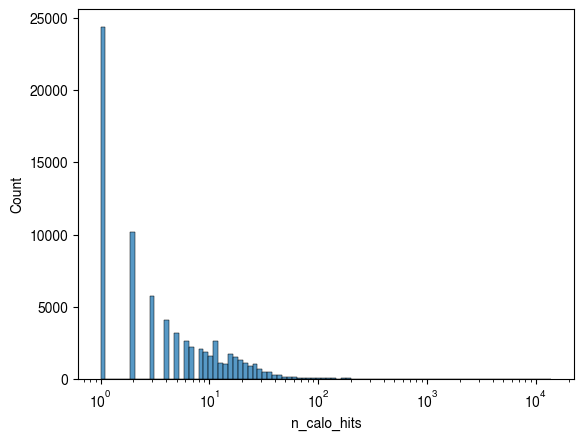

In [25]:
sns.histplot(full_particle_df.n_calo_hits, log_scale=True)

In [26]:
full_particle_df.n_tracker_hits.describe(), full_particle_df.n_calo_hits.describe()

(count    406505.000000
 mean          0.054280
 std           0.857271
 min           0.000000
 25%           0.000000
 50%           0.000000
 75%           0.000000
 max          85.000000
 Name: n_tracker_hits, dtype: float64,
 count    406505.000000
 mean          1.873308
 std          37.631502
 min           0.000000
 25%           0.000000
 50%           0.000000
 75%           0.000000
 max       13915.000000
 Name: n_calo_hits, dtype: float64)

## Process all events

In [ ]:
def process_event_for_particles(
    event_id: int,
    particles_df: pd.DataFrame,
    tracker_df: pd.DataFrame,
    calo_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Process particle data for a single event.
    
    Args:
        event_id: Event number
        particles_df: DataFrame containing particle information
        tracker_df: DataFrame containing tracker hits
        calo_df: DataFrame containing calorimeter hits
        
    Returns:
        DataFrame containing particle data for this event
    """
    # Count hits per particle
    n_tracker_hits = tracker_df.groupby("particle_id").size().reset_index(name="n_tracker_hits")
    n_calo_hits = calo_df.groupby("particle_id").size().reset_index(name="n_calo_hits")
    
    # Select relevant columns
    particle_columns = [
        "particle_id",
        "PDG",
        "mass",
        "charge",
        "vx", "vy", "vz",
        "px", "py", "pz",
        "endpoint_x", "endpoint_y", "endpoint_z",
    ]
    
    event_particles = particles_df[particle_columns].copy()
    
    # Add hit counts
    event_particles = event_particles.merge(
        n_tracker_hits, on="particle_id", how="left"
    ).merge(
        n_calo_hits, on="particle_id", how="left"
    )
    
    # Fill NaN hit counts with 0
    event_particles["n_tracker_hits"] = event_particles["n_tracker_hits"].fillna(0)
    event_particles["n_calo_hits"] = event_particles["n_calo_hits"].fillna(0)
    
    # Add event_id
    event_particles["event_id"] = event_id
    
    # Rename columns to match convention
    event_particles = event_particles.rename(columns={
        "PDG": "pdg_id",
    })
    
    return event_particles

def build_hdf5_particles(
    df: pd.DataFrame,
    output_file: str
) -> None:
    """
    Build HDF5 file with event/particle hierarchy.
    
    Structure:
    /events/
        /event_0/
            /particles    # Dataset containing particle properties
        /event_1/
            ...
            
    Args:
        df: DataFrame containing particle data
        output_file: Path to output HDF5 file
    """
    with h5py.File(output_file, 'a') as f:
        # Create events group if it doesn't exist
        if 'events' not in f:
            events_group = f.create_group('events')
        else:
            events_group = f['events']
            
        # Group DataFrame by event_id
        for event_id, event_df in df.groupby('event_id'):
            # Create event group
            event_group = events_group.create_group(f'event_{event_id}')
            
            # Store particle data
            event_group.create_dataset(
                'particles',
                data=event_df.drop(columns=['event_id']).to_records(index=False),
                compression="gzip",
                compression_opts=9
            )

def process_full_dataset_for_particles(
    base_dir: str,
    output_base_dir: str,
    chunk_size: int = 1000,
    run_size: int = 10,
    dataset_name: str = "pileup-10/ttbar/v1/reco/particles/"
) -> None:
    """
    Process entire dataset in chunks.
    
    Args:
        base_dir: Base directory containing all runs
        output_dir: Directory to save HDF5 files
        chunk_size: Number of events per chunk/file
        dataset_name: Name of the dataset (used in filename)
    """
    # Get properly sorted run directories
    run_dirs = get_run_paths(base_dir)
    num_runs = len(run_dirs)
    num_events = num_runs * run_size
    
    # Calculate runs per chunk
    runs_per_chunk = chunk_size // run_size
    
    print(f"Processing {num_runs} runs with {num_events} total events")
    print(f"Processing {runs_per_chunk} runs per chunk to get ~{chunk_size} events per file")
    
    output_dir = f"{output_base_dir}/{dataset_name}"
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    dataset_name = dataset_name.replace("/", ".")
    
    # Process chunks of runs
    for start_run in tqdm(range(0, num_runs, runs_per_chunk), desc="Processing chunks"):
        all_events_data = []
        
        # Process each run in the chunk
        for run_idx in range(start_run, min(start_run + runs_per_chunk, len(run_dirs))):
            run_dir = run_dirs[run_idx]
            print(f"Processing run {run_idx} at {run_dir}")
            
            # Load EDM4HEP file for this run
            edm4hep_file = f"{run_dir}/edm4hep.root"
            event = load_edm4hep_file(edm4hep_file, event_num=0)
            
            # Process event
            event_df = process_event_for_particles(
                run_idx * run_size,
                event["particles_df"],
                event["tracker_df"],
                event["calo_contrib_df"]
            )
            all_events_data.append(event_df)
            
        if all_events_data:
            combined_df = pd.concat(all_events_data, ignore_index=True)
            
            # Calculate event range for filename
            start_event = start_run * run_size
            end_event = min((start_run + runs_per_chunk) * run_size - 1, 
                           len(run_dirs) * run_size - 1)
            
            output_file = f"{output_dir}/{dataset_name}.events{start_event}-{end_event}.h5"
            build_hdf5_particles(combined_df, output_file)
            print(f"Saved {output_file}")